In [62]:
import torch
import torch.nn as nn

torch.manual_seed(0)

net = nn.Sequential(
    nn.Linear(1, 8),
    nn.Tanh(),
    nn.Linear(8, 1),
)

X_train = torch.rand([5, 1])
N = X_train.shape[0]

def get_grad_vec(x: torch.Tensor):
    net.zero_grad()
    out = net(x.unsqueeze(0))
    out.backward()
    grad_vec = torch.cat([p.grad.flatten() for p in net.parameters()], dim=0)
    return grad_vec



grad_vectors = torch.stack([get_grad_vec(x) for x in X_train])

K = grad_vectors @ grad_vectors.T

torch.allclose(K, K.T)
eigenvalues = torch.linalg.eigvalsh(K)
eigenvalues > 0

tensor([True, True, True, True, True])

In [43]:
for param in net.parameters():
    print(param.grad.flatten())
    grad_vec = torch.cat([p.grad.flatten() for p in net.parameters()])

grad_vec.shape

tensor([ 0.0766,  0.0869, -0.0783, -0.0603,  0.0228,  0.1260, -0.0338,  0.1176])
tensor([ 0.1386,  0.1572, -0.1417, -0.1091,  0.0413,  0.2279, -0.0611,  0.2127])
tensor([-0.0926,  0.5089, -0.6395, -0.5395, -0.8237, -0.4731, -0.3996,  0.4426])
tensor([1.])


torch.Size([25])

In [72]:
import numpy as np

A = np.array([[4, 2],
              [1, 3]]) 

eigval, eigvec = np.linalg.eig(A)

print(eigvec)

lambda1 = eigval[0]
lambda2 = eigval[1]

v1 = eigvec[:, 0]
v2 = eigvec[:, 1]

Av = A @ v1
print(Av)

lambda1 * v1


[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]
[4.47213595 2.23606798]


array([4.47213595, 2.23606798])

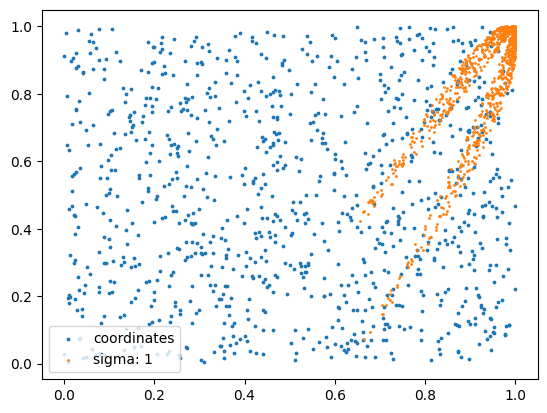

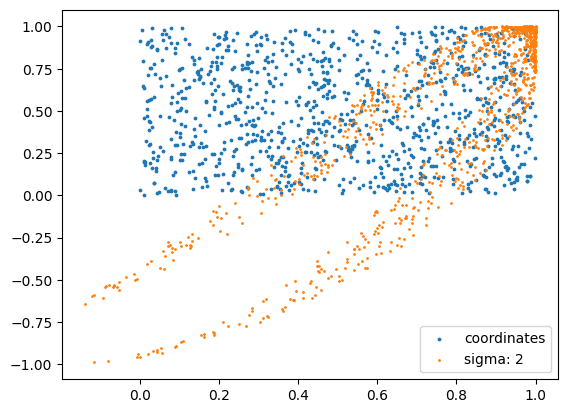

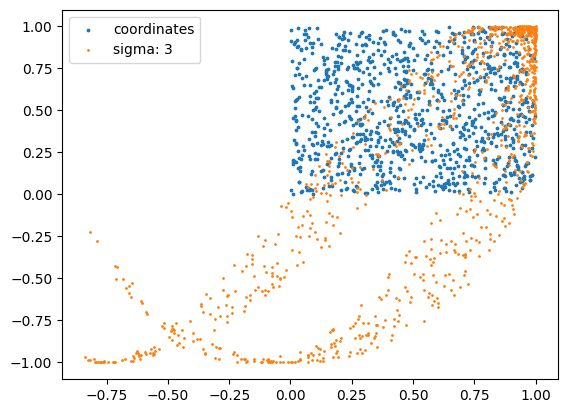

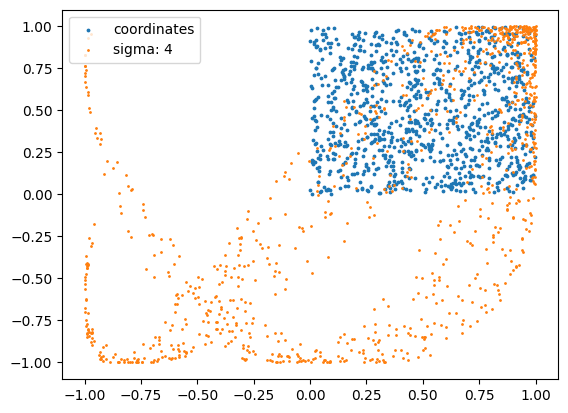

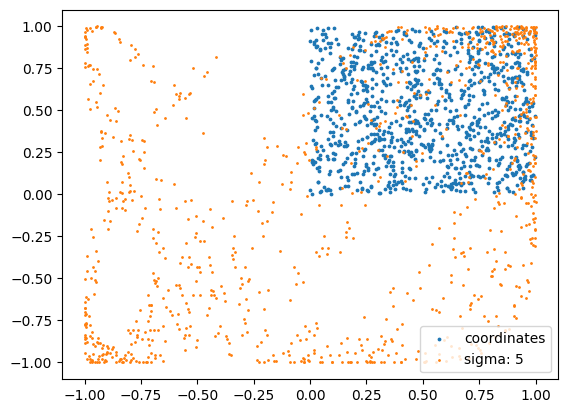

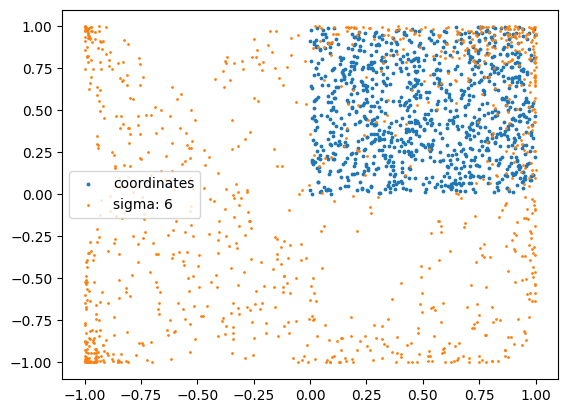

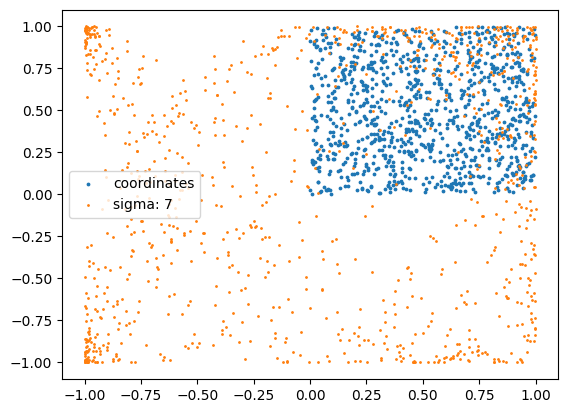

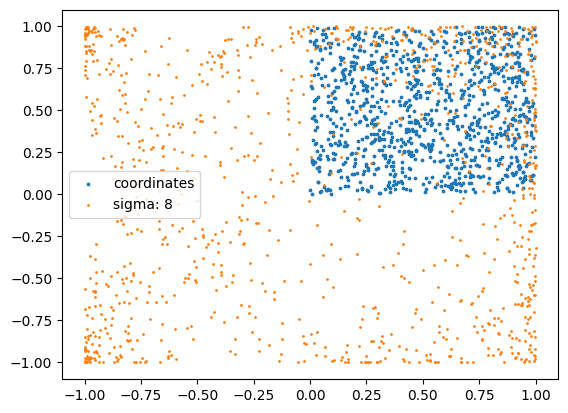

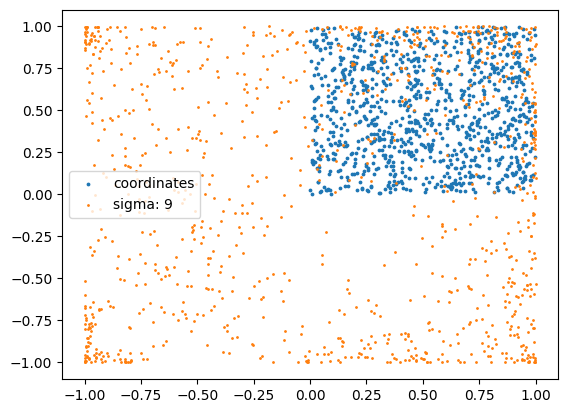

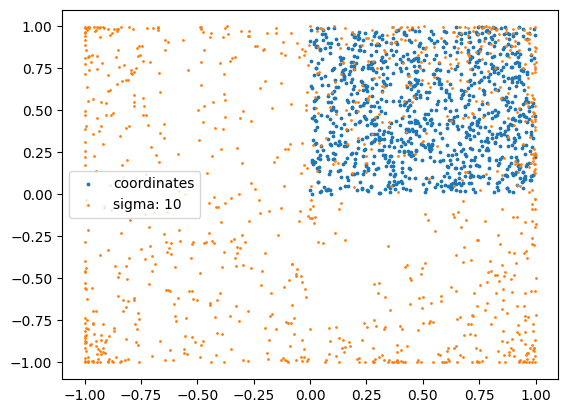

In [ ]:
# furier feature embeding...

import torch
import matplotlib.pyplot as plt

def scatter_row_wise(t, name=None, s=3):
    plt.scatter(t[0, :], t[1, :], label=name, s=s)
    plt.legend()

def scatter_col_wise(t, name=None, s=3):
    plt.scatter(t[:, 0], t[:, 1], label=name, s=s)
    plt.legend()

def ffe(x: torch.Tensor, B):
        x_proj = x @ B
        return torch.cat([torch.cos(x_proj), torch.sin(x_proj)], dim=1)

dummy_x = torch.rand([1000, 2])
g = torch.Generator().manual_seed(4)

for sigma in range(1, 11):
    scatter_col_wise(dummy_x, name='coordinates')
    B = torch.randn(size=[2, 128], generator=g) * sigma
    fourier_t = ffe(dummy_x, B)
    scatter_col_wise(fourier_t, name=f'sigma: {sigma}', s=1)
    plt.show()


In [49]:
torch.cos(new).shape

torch.Size([1000, 128])